

> ### ***Import Necessary Libraries*** ###



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import joblib
import nltk

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV, learning_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

In [2]:
nltk.download('stopwords', quiet=True)

True

In [3]:
stop_words = stopwords.words('english')
stemmer = SnowballStemmer('english')



> ### ***Import & Load Data*** ###



In [4]:
train = pd.read_csv(r'/kaggle/input/course-feedback-review/Feedback_Training.csv')

In [5]:
train.head()

,2401,Database Systems Advanced,positive,Amazing content and very well structured.
0,2401,Natural Language Processing,neutral,Average content
1,2401,Digital Marketing Strategy,negative,The pacing was too fast and unclear.
2,2401,Web Development Bootcamp,positive,Very practical and easy to follow.
3,2401,Software Engineering Principles,positive,Loved the assignments! Very interactive.
4,2401,Natural Language Processing,negative,The instructor skipped important topics.


In [6]:
train.tail()

,2401,Database Systems Advanced,positive,Amazing content and very well structured.
74667,9198,Python for Data Science,positive,Excellent instructor and clear explanations.
74668,9198,Cybersecurity Introduction,positive,Excellent instructor and clear explanations.
74669,9199,Data Visualization with Power BI,positive,Very practical and easy to follow.
74670,9199,Python for Data Science,positive,Very practical and easy to follow.
74671,9199,Database Systems Advanced,positive,Amazing content and very well structured.




> ### ***Data Preprocessing*** ###



#### ***Clean & Rename data*** ####

In [7]:
def data_cleaner(text):

    if not isinstance(text, str):
        return ""

    text = text.lower()
    # Handle emojis/emoticons
    text = text.replace("(", " sad")
    text = text.replace(";", " happy")
    text = text.replace(":3", " cute")
    text = text.replace(":d", " happy")
    text = text.replace(":-)", " happy")
    text = text.replace(":=", " happy")

    # Regex cleaning
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'[^A-Za-z0-9 ]+', ' ', text)

    # Remove stopwords and stem
    text = ' '.join([word for word in text.split() if word not in stop_words])
    text = ' '.join([stemmer.stem(word) for word in text.split()])

    return text.strip()

In [8]:
columns = ['Feedback_ID', 'Entity', 'label', 'comment']

In [9]:
train_data = pd.read_csv(r'/kaggle/input/course-feedback-review/Feedback_Training.csv', names=columns)

In [10]:
train_data.shape

(74673, 4)

In [11]:
train_data.head()

,Feedback_ID,Entity,label,comment
0,2401,Database Systems Advanced,positive,Amazing content and very well structured.
1,2401,Natural Language Processing,neutral,Average content
2,2401,Digital Marketing Strategy,negative,The pacing was too fast and unclear.
3,2401,Web Development Bootcamp,positive,Very practical and easy to follow.
4,2401,Software Engineering Principles,positive,Loved the assignments! Very interactive.


In [12]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74673 entries, 0 to 74672
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Feedback_ID  74673 non-null  int64 
 1   Entity       74673 non-null  object
 2   label        74673 non-null  object
 3   comment      73991 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB




> #### ***Drop Columns `[ Tweet_ID, Entity ]`*** ####



In [13]:
# Drop unnecessary columns
train_data.drop(['Feedback_ID', 'Entity'], axis=1, inplace=True)

In [14]:
train_data.shape

(74673, 2)

In [15]:
train_data.head()

,label,comment
0,positive,Amazing content and very well structured.
1,neutral,Average content
2,negative,The pacing was too fast and unclear.
3,positive,Very practical and easy to follow.
4,positive,Loved the assignments! Very interactive.




> #### ***Check & Drop `Null and Duplicate Values`*** ####



In [16]:
train_data.isnull().sum() # check null values

label        0
comment    682
dtype: int64

In [17]:
train_data.dropna(inplace=True)

In [18]:
print("Missing Values:\n", train_data.isnull().sum())

Missing Values:
 label      0
comment    0
dtype: int64


In [19]:
train_data.duplicated().sum() # check duplicated values

5150

In [20]:
train_data.drop_duplicates(inplace=True)

In [21]:
print("Duplicate Rows:", train_data.duplicated().sum())

Duplicate Rows: 0




> #### ***`Data Standardization`*** ####



In [22]:
# show sample
train_data.sample(5)

,label,comment
10609,Positive,"Frankly, after the shit show that was the pre-..."
48114,Negative,@HomeDepotCareer Home Depot conshohocken PA hi...
23608,Neutral,imagine taking over a particularly dumb google...
11002,Positive,I'm extremely lukewarm on.... And Outside of T...
11511,Positive,That was superb from Norton. Fun and energetic...


In [23]:
train_data['label'] = train_data['label'].str.strip().str.lower()
train_data = train_data[train_data['label'] != 'irrelevant']

In [24]:
train_data['label'].value_counts()

label
negative    21047
positive    18790
neutral     16772
Name: count, dtype: int64

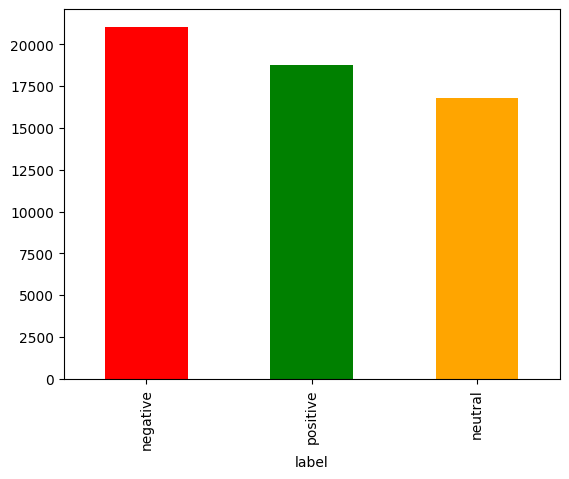

In [25]:
train_data['label'].value_counts().plot(kind='bar', color= ['red' , 'green', 'orange'])
plt.show()

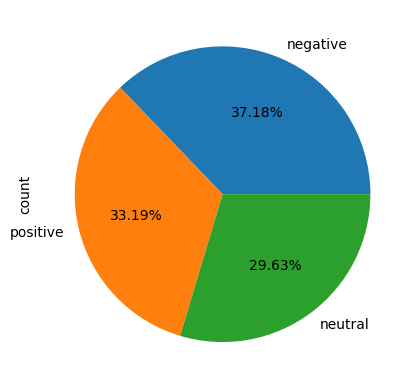

In [26]:
train_data['label'].value_counts().plot.pie(autopct='%2.2f%%',  color= ['red' , 'green', 'orange'])
plt.show()



> #### ***`Data Encoding`*** ####



In [27]:
# Apply Text Cleaning
train_data['cleaned_comment'] = train_data['comment'].apply(data_cleaner)

In [28]:
# Encode Labels (Target)
le_model = LabelEncoder()
train_data['label_code'] = le_model.fit_transform(train_data['label'])

In [29]:
train_data['label'].value_counts()

label
negative    21047
positive    18790
neutral     16772
Name: count, dtype: int64

In [30]:
train_data['label'].sample(5)

5600     positive
67572     neutral
2585     negative
63168    negative
31637    positive
Name: label, dtype: object

#### ***Feature & Target Selection*** ####

In [31]:
# Feature Selection
X = train_data['cleaned_comment']
y = train_data['label_code']

In [32]:
X.head()

0    amaz content well structur
1                averag content
2             pace fast unclear
3           practic easi follow
4          love assign interact
Name: cleaned_comment, dtype: object

In [33]:
y.head()

0    2
1    1
2    0
3    2
4    2
Name: label_code, dtype: int64

#### ***Vectorization (TF-IDF)*** ###

In [34]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=12000,
    ngram_range=(1, 2),   # unigram + bigram
    min_df=2
)

In [35]:
X_tfidf = tfidf_vectorizer.fit_transform(X)



> ### ***Spliting the dataset into the Training set and Test set*** ###



In [36]:
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape : {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (45287, 12000)
X_test shape : (11322, 12000)
y_train shape: (45287,)
y_test shape: (11322,)


> ### ***Random Forest Classifier Model*** ###


In [37]:
param_grid = {
    'n_estimators': [200, 300, 400, 500],
    'max_depth': [None, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

In [38]:
rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(class_weight='balanced', random_state=42),
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    n_jobs=-1,
    scoring='accuracy',
    verbose=1
)

In [39]:
# Fit Model
rf_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5,
                   estimator=RandomForestClassifier(class_weight='balanced',
                                                    random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'max_depth': [None, 20, 30, 40, 50],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [200, 300, 400, 500]},
                   scoring='accuracy', verbose=1)

In [40]:
rf_model = rf_search.best_estimator_
print("\nBest Parameters:", rf_search.best_params_)


Best Parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}


> ### ***Evalute the Random Forest Classifier Model*** ###

In [41]:
# train score
train_pred = rf_model.predict(X_train)
train_accuracy = accuracy_score(y_train, train_pred)
print(f"Training Accuracy: {train_accuracy:.4f}")

Training Accuracy: 0.9842


In [42]:
# test score
y_pred = rf_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Testing Accuracy: {test_accuracy:.4f}")

Testing Accuracy: 0.9420


In [43]:
print(classification_report(y_test, y_pred, target_names=le_model.classes_))

              precision    recall  f1-score   support

    negative       0.95      0.95      0.95      4235
     neutral       0.93      0.93      0.93      3304
    positive       0.95      0.94      0.94      3783

    accuracy                           0.94     11322
   macro avg       0.94      0.94      0.94     11322
weighted avg       0.94      0.94      0.94     11322



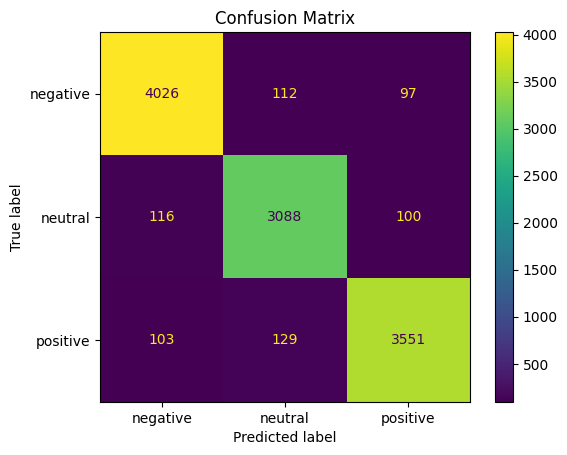

In [44]:
ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test, display_labels=le_model.classes_)
plt.title("Confusion Matrix")
plt.show()



> ### ***Save the models*** ###



In [47]:
print("Saving models to disk : ")
joblib.dump(tfidf_vectorizer, 'vectorizer.pkl')
joblib.dump(rf_model, 'rf_model.pkl')
joblib.dump(le_model, 'label_encoder.pkl')

Saving models to disk : 


['label_encoder.pkl']



> ### ***Load and Test the model*** ###



In [48]:
def predict_sentiment(text):
    cleaned_text = data_cleaner(text)
    vectorized_text = tfidf_vectorizer.transform([cleaned_text])
    predicted_index = rf_model.predict(vectorized_text)
    predicted_label = le_model.inverse_transform(predicted_index)[0]
    return predicted_label

while True:
    user_input = input("\nEnter feedback: ")
    if user_input.lower() == 'exit':
        break
    if user_input.strip():
        sentiment = predict_sentiment(user_input)
        print(f"Predicted Sentiment: {sentiment}")


Enter feedback:  this is very bad course content


Predicted Sentiment: negative



Enter feedback:  this is a good instructor 


Predicted Sentiment: positive



Enter feedback:  this is average content


Predicted Sentiment: neutral



Enter feedback:  exit
